# Val pipeline (UWGI 3D)

This notebook is for **validation visualization** (GT vs Pred) on a small, fixed set of slices.

- Picks `N=16` slices from different `caseXXX`.
- Each selected slice has **all 3 classes present** and each class area is not too small.
- Runs full-val inference to compute **mean dice** before visualization.
- Uses the repo's MONAI 3D model checkpoint and sliding-window inference.


In [1]:
import os
import random

from IPython.display import display
%matplotlib inline

import pandas as pd

import sys
sys.path.append('src')

%load_ext autoreload
%autoreload 2

from uwgi.constants import CLASSES
from uwgi.data_utils import build_case_day_slices, build_rle_index, load_case_days, parse_scan_filename
from uwgi.rle import rle_area
import uwgi.viz as viz

# ---- user config ----
data_root = './input/uw-madison-gi-tract-image-segmentation'
train_dir = os.path.join(data_root, 'train')
train_csv = os.path.join(data_root, 'train.csv')

# validation IDs: csv/txt/json (same format as training)
val_ids = os.path.join(data_root, 'splits', 'train_case_days.csv')

# model weights
MODEL_KIND = 'repo_ckpt'  # 'repo_ckpt' | 'kaggle_ref_unet_fold0'
REPO_CKPT = '/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/outputs/uwgi_train_unet/20260129-194749-3dunet-modified-rle/best.pt'
KAGGLE_WEIGHTS = '/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/kaggle_weights/uwmadison-gi-tract-image-segmentation-weights/best_weights_fold_0.pth'
weights = KAGGLE_WEIGHTS if MODEL_KIND == 'kaggle_ref_unet_fold0' else REPO_CKPT

# val sample list (pre-generated)
VAL_VIS_SAMPLES = './input/uw-madison-gi-tract-image-segmentation/splits/val_vis_samples.json'

# inference
MODE = 'sw'
ROI_SIZE_DHW = (96, 96, 96)       # (D,H,W) for repo checkpoints
ROI_SIZE_WHD = (224, 224, 80)     # (W,H,D) for kaggle reference kernel
SW_BATCH_SIZE = 1
OVERLAP = 0.25
THRESHOLD = 0.5


In [2]:
case_day_slices = build_case_day_slices(train_dir)
rle_index = build_rle_index(train_csv)

val_days = load_case_days(val_ids)
val_days = [cd for cd in val_days if cd in case_day_slices]
print('val volumes:', len(val_days))


val volumes: 216


In [3]:
import json

if not os.path.exists(VAL_VIS_SAMPLES):
    raise FileNotFoundError(f'val sample list not found: {VAL_VIS_SAMPLES}. Run scripts/select_eval_samples.py first.')

obj = json.load(open(VAL_VIS_SAMPLES, 'r', encoding='utf-8'))
samples = obj.get('samples', obj) if isinstance(obj, dict) else obj
if not isinstance(samples, list):
    raise ValueError('Unrecognized JSON format in val sample list.')

print('loaded samples:', len(samples))
pd.DataFrame(samples).head()


loaded samples: 16


,case,case_day,slice_idx,slice_pos,slice_path,present_classes,total_area,areas,min_area,min_classes
0,case122,case122_day0,82,81,./input/uw-madison-gi-tract-image-segmentation...,3,5734,"{'large_bowel': 3469, 'small_bowel': 1027, 'st...",1,3
1,case138,case138_day11,58,57,./input/uw-madison-gi-tract-image-segmentation...,3,1210,"{'large_bowel': 267, 'small_bowel': 224, 'stom...",1,3
2,case30,case30_day0,121,120,./input/uw-madison-gi-tract-image-segmentation...,3,8392,"{'large_bowel': 5006, 'small_bowel': 1701, 'st...",1,3
3,case44,case44_day20,85,84,./input/uw-madison-gi-tract-image-segmentation...,3,2979,"{'large_bowel': 1155, 'small_bowel': 164, 'sto...",1,3
4,case122,case122_day27,70,69,./input/uw-madison-gi-tract-image-segmentation...,3,3819,"{'large_bowel': 2091, 'small_bowel': 145, 'sto...",1,3


In [4]:
# Full-val inference -> mean dice (load model explicitly, then run prediction)
#
# We define both:
#  - repo UNet structure (our training/infer code)
#  - reference UNet structure (from 3d-solution-with-monai.ipynb)
# Then choose one and load weights.
RUN_FULL_EVAL = True
FORCE_RERUN_EVAL = True
EVAL_METRIC = 'kaggle_dice_2d'  # 'kaggle_dice_2d' | 'ignore_empty_3d'
COMPUTE_HAUSDORFF = True
HAUSDORFF_EMPTY_SCORE = 0.0
EVAL_OUT_BASE = './outputs/eval_runs'
EVAL_OUT = None  # set after model selection
EVAL_OUT_PER_CASE = None  # set after model selection

import csv
import json
import os
import time

import torch
from torch.utils.data import DataLoader

from monai.inferers import sliding_window_inference
from monai.networks.nets import UNet

from uwgi.datasets import UWGI3DFullVolumeDataset
from uwgi.metrics import hausdorff_score_3d_scipy_kaggle
from uwgi.models import build_model


def build_repo_unet():
    # Our repo UNet definition (src/uwgi/models.py)
    return build_model(
        model_name='unet',
        patch_size=(96, 224, 224),
        in_channels=1,
        out_channels=len(CLASSES),
        feature_size=48,
        use_checkpoint=False,
    )


def build_reference_unet():
    # Reference UNet definition from 3d-solution-with-monai.ipynb (fold weights)
    import inspect

    # Note: MONAI UNet signatures differ slightly across versions.
    # We keep the reference config, but only pass kwargs supported by the installed MONAI.
    ref_kwargs = {
        'spatial_dims': 3,
        'in_channels': 1,
        'out_channels': len(CLASSES),
        'channels': (32, 64, 128, 256, 512),
        'strides': (2, 2, 2, 2),
        'kernel_size': 3,
        'up_kernel_size': 3,
        'num_res_units': 2,
        'act': 'PRELU',
        'norm': 'BATCH',
        'dropout': 0.2,
        'bias': True,
        'dimensions': None,
    }
    allowed = set(inspect.signature(UNet.__init__).parameters.keys())
    ref_kwargs = {k: v for k, v in ref_kwargs.items() if k in allowed}
    return UNet(**ref_kwargs)


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

if MODEL_KIND == 'kaggle_ref_unet_fold0':
    model = build_reference_unet().to(device)
    ckpt = torch.load(weights, map_location='cpu')
    state = ckpt.get('model', ckpt)
    if isinstance(state, dict) and isinstance(state.get('state_dict'), dict):
        state = state['state_dict']
    if isinstance(state, dict) and state and all(str(k).startswith('module.') for k in state.keys()):
        state = {str(k)[len('module.'):]: v for k, v in state.items()}
    try:
        model.load_state_dict(state, strict=True)
    except Exception as e:
        print('[WARN] strict=True load failed, retrying strict=False:', e)
        msg = model.load_state_dict(state, strict=False)
        print('[WARN] strict=False loaded. missing_keys:', msg.missing_keys[:5], 'unexpected_keys:', msg.unexpected_keys[:5])
    MODEL_NAME = 'reference_unet'
    MODEL_SPATIAL_ORDER = 'WHD'  # kaggle kernel uses (B,C,W,H,D)
    MODEL_ROI_SIZE = ROI_SIZE_WHD
elif MODEL_KIND == 'repo_ckpt':
    from uwgi.viz import load_model_from_checkpoint

    model, _, cfg, patch_size = load_model_from_checkpoint(weights, device=str(device))
    MODEL_NAME = str((cfg or {}).get('model', 'unet') or 'unet')
    MODEL_SPATIAL_ORDER = 'DHW'
    MODEL_ROI_SIZE = ROI_SIZE_DHW
else:
    raise ValueError(f'Unknown MODEL_KIND={MODEL_KIND}')

print('MODEL_KIND:', MODEL_KIND)
print('MODEL_NAME:', MODEL_NAME)
print('weights:', weights)
print('device:', device)
print('MODEL_SPATIAL_ORDER:', MODEL_SPATIAL_ORDER)
print('MODEL_ROI_SIZE:', MODEL_ROI_SIZE)
NORMALIZE = 'volume_max' if MODEL_KIND == 'kaggle_ref_unet_fold0' else 'none'
print('NORMALIZE:', NORMALIZE)
USE_TTA = True  # flip TTA like 3d-solution-with-monai.ipynb
print('USE_TTA:', USE_TTA)

def _slug(s: str) -> str:
    s = ''.join(ch if (ch.isalnum() or ch in '._-') else '_' for ch in str(s))
    while '__' in s:
        s = s.replace('__', '_')
    return s.strip('_')

RUN_TAG = _slug(f"{MODEL_KIND}__{MODEL_NAME}__norm_{NORMALIZE}__tta_{'flip' if USE_TTA else 'none'}__{os.path.basename(str(weights))}")
EVAL_OUT_DIR = os.path.join(EVAL_OUT_BASE, RUN_TAG)
EVAL_OUT = os.path.join(EVAL_OUT_DIR, 'eval_summary.json')
EVAL_OUT_PER_CASE = os.path.join(EVAL_OUT_DIR, 'eval_per_case.csv')
print('EVAL_OUT_DIR:', EVAL_OUT_DIR)


def _dice_sum_count_kaggle_2d(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-8):
    # Kaggle-style dice: per-slice per-class over (H,W), empty-empty => 0.
    # pred/target: (B,C,D,H,W) float/bool
    pred = pred.float()
    target = target.float()
    inter = (pred * target).sum(dim=(-2, -1))  # (B,C,D)
    pred_sum = pred.sum(dim=(-2, -1))
    tgt_sum = target.sum(dim=(-2, -1))
    denom = pred_sum + tgt_sum
    dice = torch.where(denom > 0, (2.0 * inter + eps) / (denom + eps), torch.zeros_like(denom))
    count_total = torch.as_tensor(dice.numel(), device=dice.device)
    count_nonempty = (denom > 0).sum()
    gt_non_empty = (tgt_sum > 0).sum()
    return dice.sum(), count_total, count_nonempty, gt_non_empty


def _dice_sum_count_ignore_empty_3d(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-8):
    # Legacy dice over 3D volume per class, ignoring empty GT classes.
    # pred/target: (B,C,D,H,W) float/bool
    pred = pred.float()
    target = target.float()
    dims = tuple(range(2, pred.ndim))  # (D,H,W)
    inter = (pred * target).sum(dim=dims)  # (B,C)
    pred_sum = pred.sum(dim=dims)
    tgt_sum = target.sum(dim=dims)
    dice = (2.0 * inter + eps) / (pred_sum + tgt_sum + eps)
    not_empty = tgt_sum > 0
    dice = torch.where(not_empty, dice, torch.zeros_like(dice))
    return dice.sum(), not_empty.sum()


EXPECTED_METRIC = 'kaggle_score' if (EVAL_METRIC == 'kaggle_dice_2d' and COMPUTE_HAUSDORFF) else EVAL_METRIC

def _should_use_cached_summary(path: str) -> bool:
    if FORCE_RERUN_EVAL or (not os.path.exists(path)):
        return False
    try:
        obj = json.load(open(path, 'r', encoding='utf-8'))
        return (
            obj.get('weights') == weights
            and obj.get('model_kind') == MODEL_KIND
            and obj.get('model_name') == MODEL_NAME
            and obj.get('normalize') == NORMALIZE
            and bool(obj.get('tta', False)) == bool(USE_TTA)
            and obj.get('metric') == EXPECTED_METRIC
            and (not COMPUTE_HAUSDORFF or obj.get('hausdorff_impl') == 'scipy_directed_hausdorff')
            and (not COMPUTE_HAUSDORFF or float(obj.get('hausdorff_empty_score', -1)) == float(HAUSDORFF_EMPTY_SCORE))
        )
    except Exception:
        return False


if RUN_FULL_EVAL:
    os.makedirs(os.path.dirname(EVAL_OUT) or '.', exist_ok=True)
    need_run = not _should_use_cached_summary(EVAL_OUT)
    if not need_run:
        print('Using cached eval:', EVAL_OUT)
    else:
        ds = UWGI3DFullVolumeDataset(
            case_days=val_days,
            case_day_slices=case_day_slices,
            rle_index=rle_index,
            cache_in_ram=False,
            verbose_shape_fix=False,
        )
        dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

        dice_sum = 0.0
        count_total = 0
        count_nonempty_total = 0
        gt_non_empty_total = 0
        hd_score_sum = 0.0
        hd_score_count = 0
        per_case_rows = []

        model.eval()
        with torch.no_grad():
            for x, y, case_day in dl:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)
                if NORMALIZE == 'volume_max':
                    mx = x.amax(dim=(2, 3, 4), keepdim=True).clamp_min(1e-6)
                    x = x / mx

                mode = (MODE or 'sw').lower()
                x_in = x.permute(0, 1, 4, 3, 2) if MODEL_SPATIAL_ORDER == 'WHD' else x

                # Flip TTA (same idea as 3d-solution-with-monai.ipynb)
                tta_dims = [[2], [3], [2, 3]] if MODEL_SPATIAL_ORDER == 'WHD' else [[3], [4], [3, 4]]
                if not USE_TTA:
                    tta_dims = []
                dims_list = [[]] + tta_dims

                logits_sum = None
                for dims in dims_list:
                    x_f = torch.flip(x_in, dims=dims) if dims else x_in
                    if mode == 'direct':
                        l = model(x_f)
                    elif mode == 'sw':
                        l = sliding_window_inference(x_f, MODEL_ROI_SIZE, SW_BATCH_SIZE, model, overlap=OVERLAP)
                    else:
                        raise ValueError(f'Unknown MODE={MODE}')
                    if dims:
                        l = torch.flip(l, dims=dims)
                    logits_sum = l if logits_sum is None else (logits_sum + l)

                logits = logits_sum / float(len(dims_list))
                if MODEL_SPATIAL_ORDER == 'WHD':
                    logits = logits.permute(0, 1, 4, 3, 2)

                pred = (torch.sigmoid(logits) > THRESHOLD).float()
                if EVAL_METRIC == 'kaggle_dice_2d':
                    s, c_total, c_nonempty, gt_ne = _dice_sum_count_kaggle_2d(pred, y)
                    dice_sum += float(s.item())
                    count_total += int(c_total.item())
                    count_nonempty_total += int(c_nonempty.item())
                    gt_non_empty_total += int(gt_ne.item())
                    case_dice = float(s.item()) / max(1, int(c_total.item()))
                    case_dice_nonempty = float(s.item()) / max(1, int(c_nonempty.item()))
                elif EVAL_METRIC == 'ignore_empty_3d':
                    s, c_ne = _dice_sum_count_ignore_empty_3d(pred, y)
                    dice_sum += float(s.item())
                    gt_non_empty_total += int(c_ne.item())
                    case_dice = float(s.item()) / max(1, int(c_ne.item()))
                    case_dice_nonempty = None
                else:
                    raise ValueError(f'Unknown EVAL_METRIC={EVAL_METRIC}')

                case_hd_score = None
                if COMPUTE_HAUSDORFF:
                    pred_vol = (pred[0] > 0.5).detach().cpu().numpy().astype('uint8')
                    gt_vol = (y[0] > 0.5).detach().cpu().numpy().astype('uint8')
                    hd_by_cls, case_hd_score = hausdorff_score_3d_scipy_kaggle(
                        pred_vol,
                        gt_vol,
                        empty_score=HAUSDORFF_EMPTY_SCORE,
                        return_per_class=True,
                    )
                    hd_score_sum += float(hd_by_cls.sum())
                    hd_score_count += int(hd_by_cls.size)
                    case_hd_score = float(case_hd_score)

                case_final_score = None
                if COMPUTE_HAUSDORFF and EVAL_METRIC == 'kaggle_dice_2d' and case_hd_score is not None:
                    case_final_score = 0.4 * float(case_dice) + 0.6 * float(case_hd_score)
                name = case_day[0] if isinstance(case_day, (list, tuple)) else str(case_day)
                per_case_rows.append(
                    {
                        'case_day': name,
                        'dice': case_dice,
                        'dice_nonempty': case_dice_nonempty,
                        'hausdorff_score': case_hd_score,
                        'final_score': case_final_score,
                        'count_total': int(c_total.item()) if EVAL_METRIC == 'kaggle_dice_2d' else None,
                        'count_nonempty': int(c_nonempty.item()) if EVAL_METRIC == 'kaggle_dice_2d' else None,
                        'gt_non_empty': int(gt_ne.item()) if EVAL_METRIC == 'kaggle_dice_2d' else int(c_ne.item()),
                        'num_slices': int(y.shape[2]),
                        'num_classes': int(y.shape[1]),
                    }
                )

        if EVAL_METRIC == 'kaggle_dice_2d':
            mean_dice_all = dice_sum / max(1, count_total)
            mean_dice_nonempty = dice_sum / max(1, count_nonempty_total)
            empty_empty_pairs = int(count_total - count_nonempty_total)
            mean_dice = float(mean_dice_all)  # backward-compatible alias
        else:
            mean_dice_all = None
            mean_dice_nonempty = None
            empty_empty_pairs = None
            mean_dice = dice_sum / max(1, gt_non_empty_total)

        mean_hausdorff_score = (hd_score_sum / max(1, hd_score_count)) if COMPUTE_HAUSDORFF else None
        final_score = None
        if COMPUTE_HAUSDORFF and EVAL_METRIC == 'kaggle_dice_2d':
            final_score = 0.4 * float(mean_dice_all) + 0.6 * float(mean_hausdorff_score)
        summary = {
            'timestamp': int(time.time()),
            'data_root': data_root,
            'weights': weights,
            'model_kind': MODEL_KIND,
            'model_name': MODEL_NAME,
            'model_class': type(model).__name__,
            'normalize': NORMALIZE,
            'tta': bool(USE_TTA),
            'metric': EXPECTED_METRIC,
            'score_weights': {'dice': 0.4, 'hausdorff': 0.6},
            'mode': MODE,
            'roi_size': list(MODEL_ROI_SIZE),
            'spatial_order': MODEL_SPATIAL_ORDER,
            'sw_batch_size': int(SW_BATCH_SIZE),
            'overlap': float(OVERLAP),
            'threshold': float(THRESHOLD),
            'mean_dice': float(mean_dice),
            'mean_dice_all': float(mean_dice_all) if mean_dice_all is not None else None,
            'mean_dice_nonempty': float(mean_dice_nonempty) if mean_dice_nonempty is not None else None,
            'count_nonempty': int(count_nonempty_total) if EVAL_METRIC == 'kaggle_dice_2d' else None,
            'empty_empty_pairs': int(empty_empty_pairs) if empty_empty_pairs is not None else None,
            'mean_hausdorff_score': float(mean_hausdorff_score) if mean_hausdorff_score is not None else None,
            'final_score': float(final_score) if final_score is not None else None,
            'hausdorff_impl': 'scipy_directed_hausdorff' if COMPUTE_HAUSDORFF else None,
            'hausdorff_empty_score': float(HAUSDORFF_EMPTY_SCORE) if COMPUTE_HAUSDORFF else None,
            'count_total': int(count_total),
            'gt_non_empty': int(gt_non_empty_total),
            'hd_score_count': int(hd_score_count),
            'num_case_days': int(len(per_case_rows)),
        }

        os.makedirs(os.path.dirname(EVAL_OUT_PER_CASE) or '.', exist_ok=True)
        with open(EVAL_OUT_PER_CASE, 'w', encoding='utf-8', newline='') as f:
            w = csv.DictWriter(
                f,
                fieldnames=['case_day', 'dice', 'dice_nonempty', 'hausdorff_score', 'final_score', 'count_total', 'count_nonempty', 'gt_non_empty', 'num_slices', 'num_classes'],
            )
            w.writeheader()
            w.writerows(per_case_rows)

        with open(EVAL_OUT, 'w', encoding='utf-8') as f:
            json.dump(summary, f, indent=2, ensure_ascii=False)
        print('Saved summary:', EVAL_OUT)
        print('Saved per-case:', EVAL_OUT_PER_CASE)

summary = json.load(open(EVAL_OUT, 'r', encoding='utf-8'))
print(
    'mean_dice(all):',
    summary.get('mean_dice_all', summary.get('mean_dice')),
    '| mean_dice_nonempty:',
    summary.get('mean_dice_nonempty'),
    '| mean_hausdorff_score:',
    summary.get('mean_hausdorff_score'),
    '| final_score:',
    summary.get('final_score'),
    '| count_total:',
    summary.get('count_total'),
    '| count_nonempty:',
    summary.get('count_nonempty'),
    '| empty_empty_pairs:',
    summary.get('empty_empty_pairs'),
    '| gt_non_empty:',
    summary.get('gt_non_empty'),
    '| num_case_days:',
    summary.get('num_case_days'),
    '| metric:',
    summary.get('metric'),
)
summary


/home/jeremiah/miniconda/envs/segmentation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODEL_KIND: repo_ckpt
MODEL_NAME: unet
weights: /home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/outputs/uwgi_train_unet/20260129-194749-3dunet-modified-rle/best.pt
device: cuda:0
MODEL_SPATIAL_ORDER: DHW
MODEL_ROI_SIZE: (96, 96, 96)
NORMALIZE: none
USE_TTA: True
EVAL_OUT_DIR: ./outputs/eval_runs/repo_ckpt_unet_norm_none_tta_flip_best.pt


/home/jeremiah/miniconda/envs/segmentation/lib/python3.10/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/home/jeremiah/miniconda/envs/segmentation/lib/python3.10/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variab

Saved summary: ./outputs/eval_runs/repo_ckpt_unet_norm_none_tta_flip_best.pt/eval_summary.json
Saved per-case: ./outputs/eval_runs/repo_ckpt_unet_norm_none_tta_flip_best.pt/eval_per_case.csv
mean_dice(all): 0.18085558146322514 | mean_dice_nonempty: 0.45785558048225594 | mean_hausdorff_score: 0.8022235210663007 | final_score: 0.5536763452250705 | count_total: 90624 | count_nonempty: 35797 | empty_empty_pairs: 54827 | gt_non_empty: 26542 | num_case_days: 216 | metric: kaggle_score


{'timestamp': 1769907114,
 'data_root': './input/uw-madison-gi-tract-image-segmentation',
 'weights': '/home/jeremiah/github/UW-Madison_GI_Tract_Image_Segmentation/outputs/uwgi_train_unet/20260129-194749-3dunet-modified-rle/best.pt',
 'model_kind': 'repo_ckpt',
 'model_name': 'unet',
 'model_class': 'UNet',
 'normalize': 'none',
 'tta': True,
 'metric': 'kaggle_score',
 'score_weights': {'dice': 0.4, 'hausdorff': 0.6},
 'mode': 'sw',
 'roi_size': [96, 96, 96],
 'spatial_order': 'DHW',
 'sw_batch_size': 1,
 'overlap': 0.25,
 'threshold': 0.5,
 'mean_dice': 0.18085558146322514,
 'mean_dice_all': 0.18085558146322514,
 'mean_dice_nonempty': 0.45785558048225594,
 'count_nonempty': 35797,
 'empty_empty_pairs': 54827,
 'mean_hausdorff_score': 0.8022235210663007,
 'final_score': 0.5536763452250705,
 'hausdorff_impl': 'scipy_directed_hausdorff',
 'hausdorff_empty_score': 0.0,
 'count_total': 90624,
 'gt_non_empty': 26542,
 'hd_score_count': 648,
 'num_case_days': 216}

saved: ./outputs/eval_runs/repo_ckpt_unet_norm_none_tta_flip_best.pt/volumes/case101_day20/pred_CDHW.npy
saved: ./outputs/eval_runs/repo_ckpt_unet_norm_none_tta_flip_best.pt/volumes/case101_day20/gt_CDHW.npy
case_day: case101_day20 | hausdorff3d_score_mean: 0.7040767073631287 | per_cls: {'large_bowel': 0.88289475440979, 'small_bowel': 0.6886736154556274, 'stomach': 0.5406617522239685}
slice_pos= 90 | dice2d_mean= 0.5456 | dice2d_by_cls= {'large_bowel': 0.7753954529762268, 'small_bowel': 6.1124694715475325e-12, 'stomach': 0.8613366484642029} | final_score(0.4*dice+0.6*hausdorff)= 0.6407


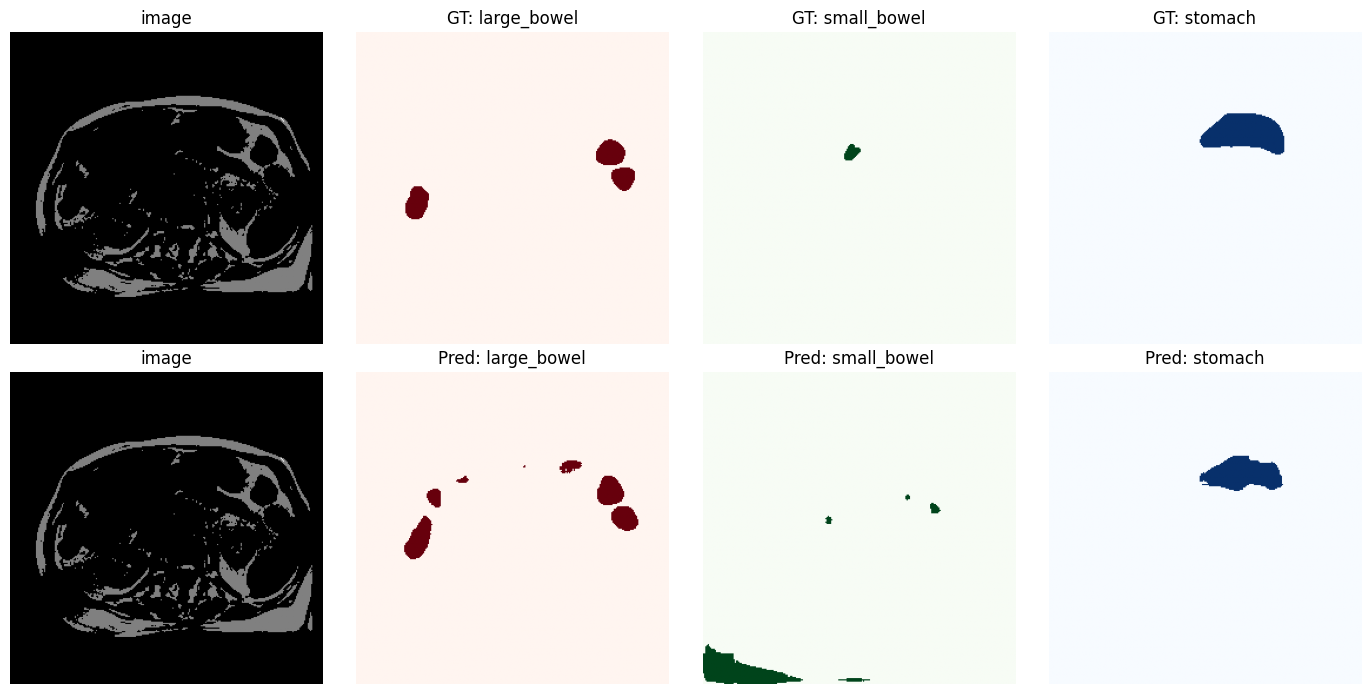

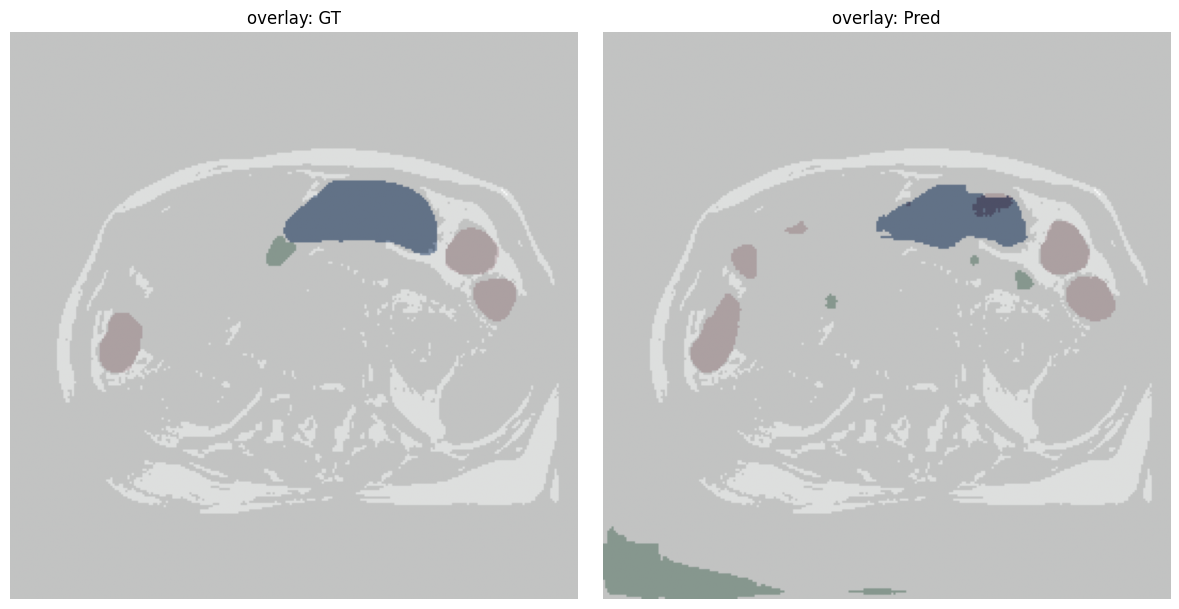

In [5]:
# Inspect a specific case_day volume: save pred/gt + plot selected slices

import os
import numpy as np
import matplotlib.pyplot as plt

INSPECT_CASE_DAY = (val_days[0] if len(val_days) else '')  # e.g. 'case122_day0'
SLICE_POS_LIST = [90]  # list of slice_pos (0..D-1)
SLICE_IDX_LIST = []   # optional: kaggle slice_idx list; if set, overrides SLICE_POS_LIST
SAVE_VOLUME_NPY = True

if not INSPECT_CASE_DAY:
    raise ValueError('INSPECT_CASE_DAY is empty')
if INSPECT_CASE_DAY not in case_day_slices:
    raise KeyError(f'case_day not found: {INSPECT_CASE_DAY}')

out_dir = os.path.join(EVAL_OUT_DIR, 'volumes', INSPECT_CASE_DAY)
os.makedirs(out_dir, exist_ok=True)

pred_vol, gt_vol, _ = viz.predict_case_day_volume(
    INSPECT_CASE_DAY,
    case_day_slices=case_day_slices,
    rle_index=rle_index,
    model=model,
    mode=MODE,
    roi_size=MODEL_ROI_SIZE,
    sw_batch_size=SW_BATCH_SIZE,
    overlap=OVERLAP,
    threshold=THRESHOLD,
    spatial_order=MODEL_SPATIAL_ORDER,
    normalize=NORMALIZE,
    tta=USE_TTA,
)

if SAVE_VOLUME_NPY:
    np.save(os.path.join(out_dir, 'pred_CDHW.npy'), pred_vol)
    np.save(os.path.join(out_dir, 'gt_CDHW.npy'), gt_vol)
    print('saved:', os.path.join(out_dir, 'pred_CDHW.npy'))
    print('saved:', os.path.join(out_dir, 'gt_CDHW.npy'))


def _slice_pos_from_slice_idx(case_day: str, slice_idx: int) -> int:
    for pos, p in enumerate(case_day_slices[case_day]):
        idx, _, _ = parse_scan_filename(p)
        if int(idx) == int(slice_idx):
            return int(pos)
    raise KeyError(f'slice_idx={slice_idx} not found in {case_day}')


slice_positions = []
if SLICE_IDX_LIST:
    slice_positions = [_slice_pos_from_slice_idx(INSPECT_CASE_DAY, int(x)) for x in SLICE_IDX_LIST]
else:
    slice_positions = [int(x) for x in SLICE_POS_LIST]

from uwgi.metrics import dice_per_class_2d_kaggle, hausdorff_score_3d_scipy_kaggle

hd_by_cls, hd_score_mean = hausdorff_score_3d_scipy_kaggle(
    pred_vol,
    gt_vol,
    empty_score=HAUSDORFF_EMPTY_SCORE,
    return_per_class=True,
)
print('case_day:', INSPECT_CASE_DAY, '| hausdorff3d_score_mean:', float(hd_score_mean), '| per_cls:', {CLASSES[i]: float(hd_by_cls[i]) for i in range(len(CLASSES))})

for sp in slice_positions:
    dice_by_cls = dice_per_class_2d_kaggle(pred_vol[:, sp], gt_vol[:, sp])
    dice_mean = float(dice_by_cls.mean())
    final_score = 0.4 * dice_mean + 0.6 * float(hd_score_mean)
    print(
        'slice_pos=',
        int(sp),
        '| dice2d_mean=',
        f'{dice_mean:.4f}',
        '| dice2d_by_cls=',
        {CLASSES[i]: float(dice_by_cls[i]) for i in range(len(CLASSES))},
        '| final_score(0.4*dice+0.6*hausdorff)=',
        f'{final_score:.4f}',
    )
    fig_grid, fig_overlay, *_ = viz.plot_case_day_slice_gt_pred(
        INSPECT_CASE_DAY,
        slice_pos=int(sp),
        case_day_slices=case_day_slices,
        rle_index=rle_index,
        pred_vol=pred_vol,
        gt_vol=gt_vol,
        mode=MODE,
        roi_size=MODEL_ROI_SIZE,
        sw_batch_size=SW_BATCH_SIZE,
        overlap=OVERLAP,
        threshold=THRESHOLD,
        spatial_order=MODEL_SPATIAL_ORDER,
    )
    display(fig_grid)
    display(fig_overlay)
    plt.close(fig_grid)
    plt.close(fig_overlay)


0 case122_day0 slice_pos= 81 slice_idx= 82 | dice2d_mean= 0.3784 | dice2d_by_cls= {'large_bowel': 0.3161029517650604, 'small_bowel': 0.6197183132171631, 'stomach': 0.19927272200584412} | hausdorff3d_score= 0.8198 | hausdorff3d_by_cls= {'large_bowel': 0.7653065919876099, 'small_bowel': 0.9493690133094788, 'stomach': 0.7447137236595154} | final_score(0.4*dice+0.6*hausdorff)= 0.6432


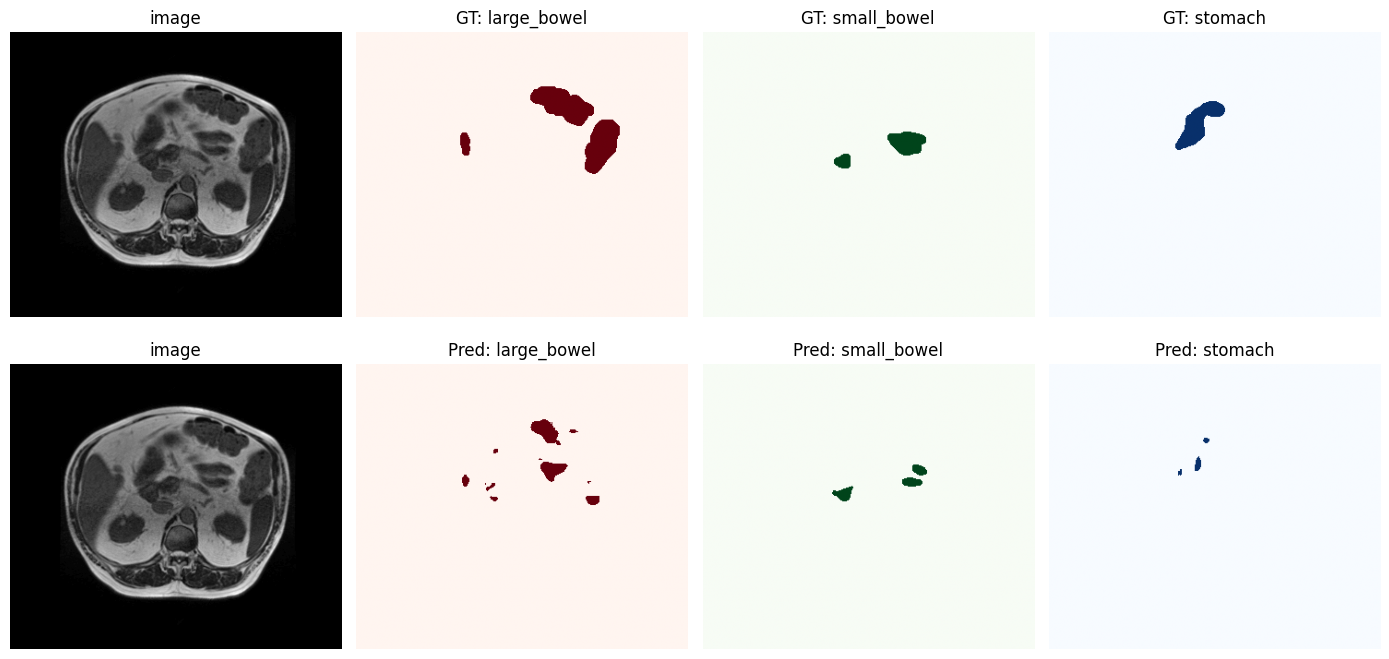

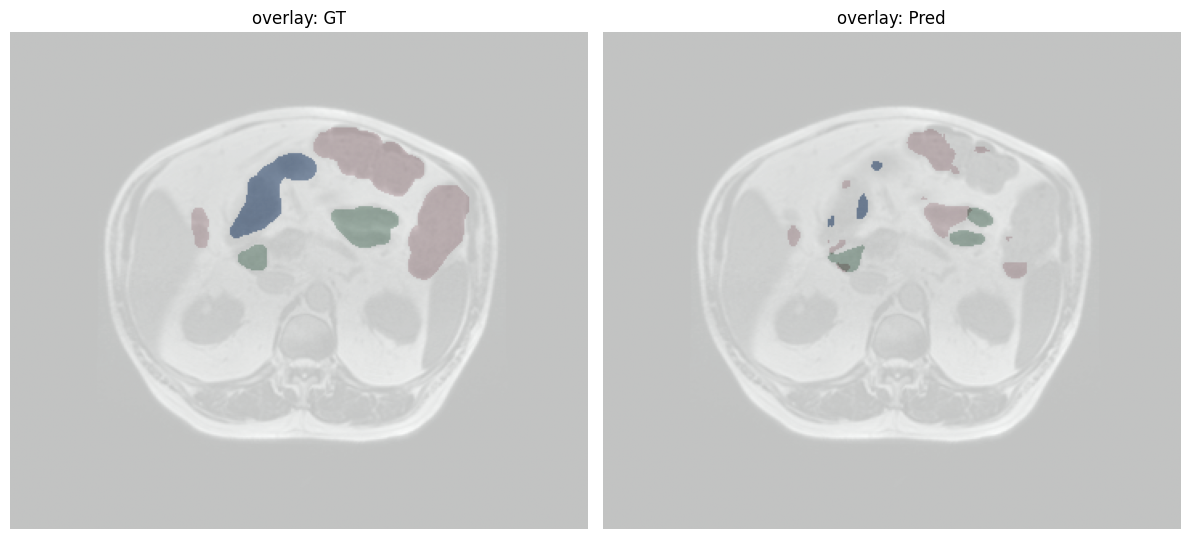

In [6]:
# Visualize a few (this runs sliding-window inference per sample; start small)

N_VIS = 1
seen = set()
uniq_samples = []
for s in samples:
    key = (str(s.get('case_day')), int(s.get('slice_pos', -1)))
    if key in seen:
        continue
    seen.add(key)
    uniq_samples.append(s)
    if len(uniq_samples) >= int(N_VIS):
        break

import matplotlib.pyplot as plt

from uwgi.metrics import dice_per_class_2d_kaggle, hausdorff_score_3d_scipy_kaggle

cache = {}  # case_day -> {'pred': (C,D,H,W), 'gt': (C,D,H,W), 'hd_by_cls': (C,), 'hd_score_mean': float}

for i, s in enumerate(uniq_samples):
    case_day = s['case_day']
    slice_pos = int(s['slice_pos'])
    slice_idx = int(s.get('slice_idx', -1))

    if case_day not in cache:
        pred_vol, gt_vol, _ = viz.predict_case_day_volume(
            case_day,
            case_day_slices=case_day_slices,
            rle_index=rle_index,
            model=model,
            mode=MODE,
            roi_size=MODEL_ROI_SIZE,
            sw_batch_size=SW_BATCH_SIZE,
            overlap=OVERLAP,
            threshold=THRESHOLD,
            spatial_order=MODEL_SPATIAL_ORDER,
            normalize=NORMALIZE,
            tta=USE_TTA,
        )
        hd_by_cls, hd_score_mean = hausdorff_score_3d_scipy_kaggle(pred_vol, gt_vol, empty_score=0.0, return_per_class=True)
        cache[case_day] = {
            'pred': pred_vol,
            'gt': gt_vol,
            'hd_by_cls': hd_by_cls,
            'hd_score_mean': float(hd_score_mean),
        }

    pred_vol = cache[case_day]['pred']
    gt_vol = cache[case_day]['gt']
    hd_score = float(cache[case_day]['hd_score_mean'])

    dice_by_cls = dice_per_class_2d_kaggle(pred_vol[:, slice_pos], gt_vol[:, slice_pos])
    dice_mean = float(dice_by_cls.mean())
    final_score = 0.4 * float(dice_mean) + 0.6 * float(hd_score)

    print(
        i,
        case_day,
        'slice_pos=',
        slice_pos,
        'slice_idx=',
        slice_idx,
        '| dice2d_mean=',
        f'{dice_mean:.4f}',
        '| dice2d_by_cls=',
        {CLASSES[j]: float(dice_by_cls[j]) for j in range(len(CLASSES))},
        '| hausdorff3d_score=',
        f"{hd_score:.4f}",
        '| hausdorff3d_by_cls=',
        {CLASSES[j]: float(cache[case_day]['hd_by_cls'][j]) for j in range(len(CLASSES))},
        '| final_score(0.4*dice+0.6*hausdorff)=',
        f"{final_score:.4f}",
    )

    fig_grid, fig_overlay, *_ = viz.plot_case_day_slice_gt_pred(
        case_day,
        slice_pos=slice_pos,
        case_day_slices=case_day_slices,
        rle_index=rle_index,
        pred_vol=pred_vol,
        gt_vol=gt_vol,
        mode=MODE,
        roi_size=MODEL_ROI_SIZE,
        sw_batch_size=SW_BATCH_SIZE,
        overlap=OVERLAP,
        threshold=THRESHOLD,
        spatial_order=MODEL_SPATIAL_ORDER,
    )
    display(fig_grid)
    display(fig_overlay)
    plt.close(fig_grid)
    plt.close(fig_overlay)
